In [2]:
### IMPORT EXTERNAL FUNCTIONS
import mne
import numpy as np
from os.path import join
import os
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
import scipy
from functions import utils


## Load full stream and crop into blocks

In [14]:
# Session to preprocess
session_id = "sub027 DBS ON mSST"

working_path = os.path.dirname(os.getcwd())
onedrive_path = utils._get_onedrive_path()
sub = session_id.split(' ') [0]

if session_id.startswith('sub'):
    condition = session_id.split(' ') [1] + ' ' + session_id.split(' ') [2]
    sub_onedrive_path_task = join(onedrive_path, sub, 'synced_data', session_id)
elif session_id.startswith('C'):
    condition = session_id
    sub_onedrive_path_task = join(onedrive_path, sub, 'synced_data', condition)

#  Set saving path
results_path = join(working_path, "results")
saving_path = join(results_path, "eeg_output", "single_sub")
if not os.path.isdir(saving_path):
    os.makedirs(saving_path)
sub_save_path = join(saving_path, "figures")
os.makedirs(sub_save_path, exist_ok=True)  # Create the directory if it doesn't exist

save_path = os.path.join(saving_path,"data")
os.makedirs(save_path, exist_ok=True)  # Create the directory if it doesn't exist

# Load raw data
filename = [f for f in os.listdir(sub_onedrive_path_task) if (
    f.endswith('.set') and f.startswith('SYNCHRONIZED_EXTERNAL'))]
file = join(sub_onedrive_path_task, filename[0])
raw = mne.io.read_raw(file, preload=True)


In [ ]:
# session_id = "sub019 DBS ON MID"

# # Paths personal comp.
# #data_path = "/Users/charlotte/Library/CloudStorage/OneDrive-Charité-UniversitätsmedizinBerlin/WP3 Task Force/DATA"
# #saving_path = "/Users/charlotte/Library/CloudStorage/OneDrive-Charité-UniversitätsmedizinBerlin/phd_charite/WP3/eeg_output/single_sub"

# # Paths work. comp. 
# data_path = "C:\\Users\\chst14\\OneDrive - Charité - Universitätsmedizin Berlin\\WP3 Task Force\\DATA"
# saving_path = "C:\\Users\\chst14\\OneDrive - Charité - Universitätsmedizin Berlin\\phd_charite\\WP3\\eeg_output\\single_sub"

# # Set saving path variables
# sub = session_id.split(' ') [0]
# if "C" in session_id:
#     condition = "noDBS"
# else:
#     condition = session_id.split(' ') [1] + ' ' + session_id.split(' ') [2]

# # Load EEG raw data
# sub_data_path = join(data_path, sub, "synced_data", session_id)
# filename = [f for f in os.listdir(sub_data_path) if (
#     f.endswith('.set') and f.startswith('SYNCHRONIZED_EXTERNAL'))]
# file = join(sub_data_path, filename[0])
# raw = mne.io.read_raw(file, preload=True)   


### Annotate breaks

In [15]:
# t_start_after_previous defines how much time after the previous annotation the break should start
# t_stop_before_next defines how much time before the next annotation the break should stop
# = how much time without events do we want at beginning and end of each (in our case) blocks.

break_annot = mne.preprocessing.annotate_break(raw, min_break_duration=10, t_start_after_previous=4, t_stop_before_next=4)
raw_breaks = raw.set_annotations(raw.annotations + break_annot)

Ignoring annotations with descriptions starting with: bad, edge

Detected 4 break periods of >= 10 s duration:
    0.0 – 63.7 s [63.7 s]
    464.1 – 768.8 s [304.7 s]
    1164.6 – 1197.4 s [32.8 s]
    1585.2 – 1621.2 s [36.0 s]
In total, 27.0% of the data (437.2 s) have been marked as a break.



### Visual check that breaks are correctly marked

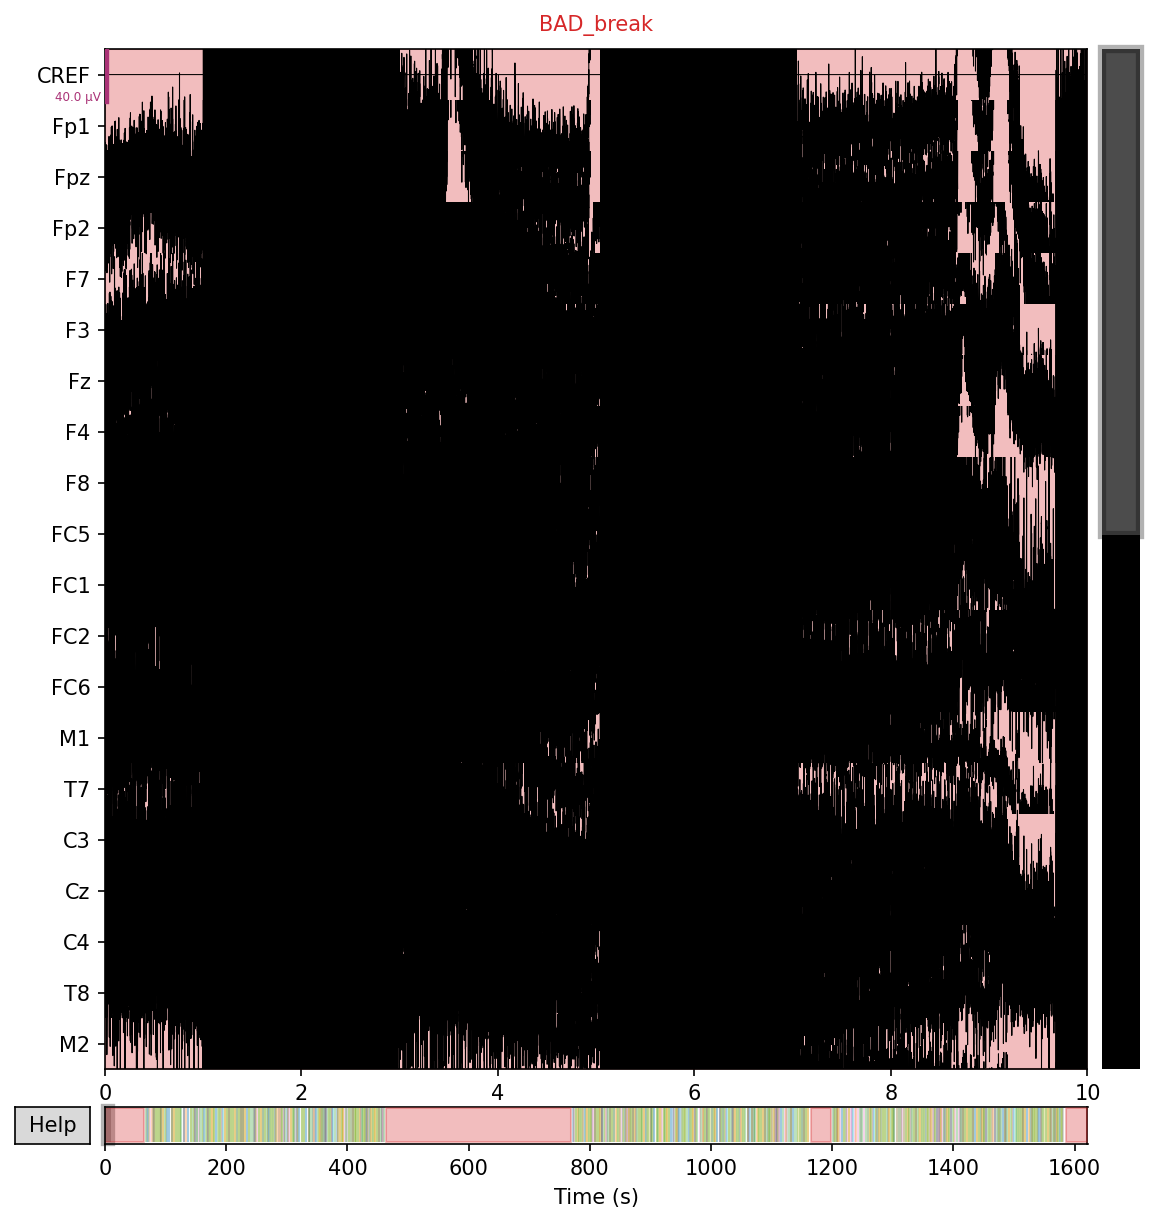

Channels marked as bad:
none


In [16]:
raw_breaks.plot()

In [17]:
# Get break start/end times
break_on = break_annot.onset
break_off = break_annot.onset + break_annot.duration

In [18]:
# Sort breaks in chronological order
# so that when we use them later to index breaks in the data, they are in the correct order
idx = np.argsort(break_on)
break_on = break_on[idx]
break_off = break_off[idx]

# Double check that breaks are in the right place (first break should be at start, second in middle etc.)
print(f"Break start times (s): {break_on}")
print(f"Break end times (s): {break_off}")

Break start times (s): [   0.        464.072128 1164.60103  1585.184542]
Break end times (s): [  63.721432    768.788386   1197.401948   1621.16058424]


In [19]:
# Define block windows
t1_start, t1_stop = break_off[0], break_on[1]   # after break1 (=beginning of stream) until break2 (=halfway break) starts
t2_start, t2_stop = break_off[1], break_on[2]   # after break2 (=halfway break) until break3 (=end of stream) starts
t3_start, t3_stop = break_off[2], break_on[3]   # after break3 (=end of stream) until the end of recording

## Here add something in case there are 4 blocks instead of 3

print(f"Block 1: {t1_start:.1f} – {t1_stop:.1f} s")
print(f"Block 2: {t2_start:.1f} – {t2_stop:.1f} s")
print(f"Block 3: {t3_start:.1f} – {t3_stop:.1f} s")

Block 1: 63.7 – 464.1 s
Block 2: 768.8 – 1164.6 s
Block 3: 1197.4 – 1585.2 s


### Crop

In [20]:
# Crop into two Raw objects
raw_block1 = raw_breaks.copy().crop(tmin=t1_start, tmax=t1_stop, include_tmax=False)
raw_block2 = raw_breaks.copy().crop(tmin=t2_start, tmax=t2_stop, include_tmax=False)
raw_block3 = raw_breaks.copy().crop(tmin=t3_start, tmax=t3_stop, include_tmax=False)

# add something in case there are 4 blocks instead of 3

### Save blocks and timings

In [21]:
# Save blocks
save_folder = join(saving_path, sub, condition, "raw_blocks") 
os.makedirs(save_folder, exist_ok=True)
 
raw_block1.save(f"{save_folder}/{sub}_{condition}_mSST_block1_raw.fif", overwrite=True)
raw_block2.save(f"{save_folder}/{sub}_{condition}_mSST_block2_raw.fif", overwrite=True)
raw_block3.save(f"{save_folder}/{sub}_{condition}_mSST_block3_raw.fif", overwrite=True)

# add something in case there are 4 blocks instead of 3

# Save block timings into .txt file
with open(f"{save_folder}/{sub}_{condition}_block_timings.txt", "w") as f:
    f.write(f"Block 1: {t1_start:.1f} – {t1_stop:.1f} s\n")
    f.write(f"Block 2: {t2_start:.1f} – {t2_stop:.1f} s\n")
    f.write(f"Block 3: {t3_start:.1f} – {t3_stop:.1f} s\n")

Writing c:\Users\Juliette\Research\Projects\analysis_mSST\results\eeg_output\single_sub\sub027\DBS ON\raw_blocks\sub027_DBS ON_mSST_block1_raw.fif
Closing c:\Users\Juliette\Research\Projects\analysis_mSST\results\eeg_output\single_sub\sub027\DBS ON\raw_blocks\sub027_DBS ON_mSST_block1_raw.fif
[done]
Writing c:\Users\Juliette\Research\Projects\analysis_mSST\results\eeg_output\single_sub\sub027\DBS ON\raw_blocks\sub027_DBS ON_mSST_block2_raw.fif
Closing c:\Users\Juliette\Research\Projects\analysis_mSST\results\eeg_output\single_sub\sub027\DBS ON\raw_blocks\sub027_DBS ON_mSST_block2_raw.fif
[done]
Writing c:\Users\Juliette\Research\Projects\analysis_mSST\results\eeg_output\single_sub\sub027\DBS ON\raw_blocks\sub027_DBS ON_mSST_block3_raw.fif
Closing c:\Users\Juliette\Research\Projects\analysis_mSST\results\eeg_output\single_sub\sub027\DBS ON\raw_blocks\sub027_DBS ON_mSST_block3_raw.fif
[done]


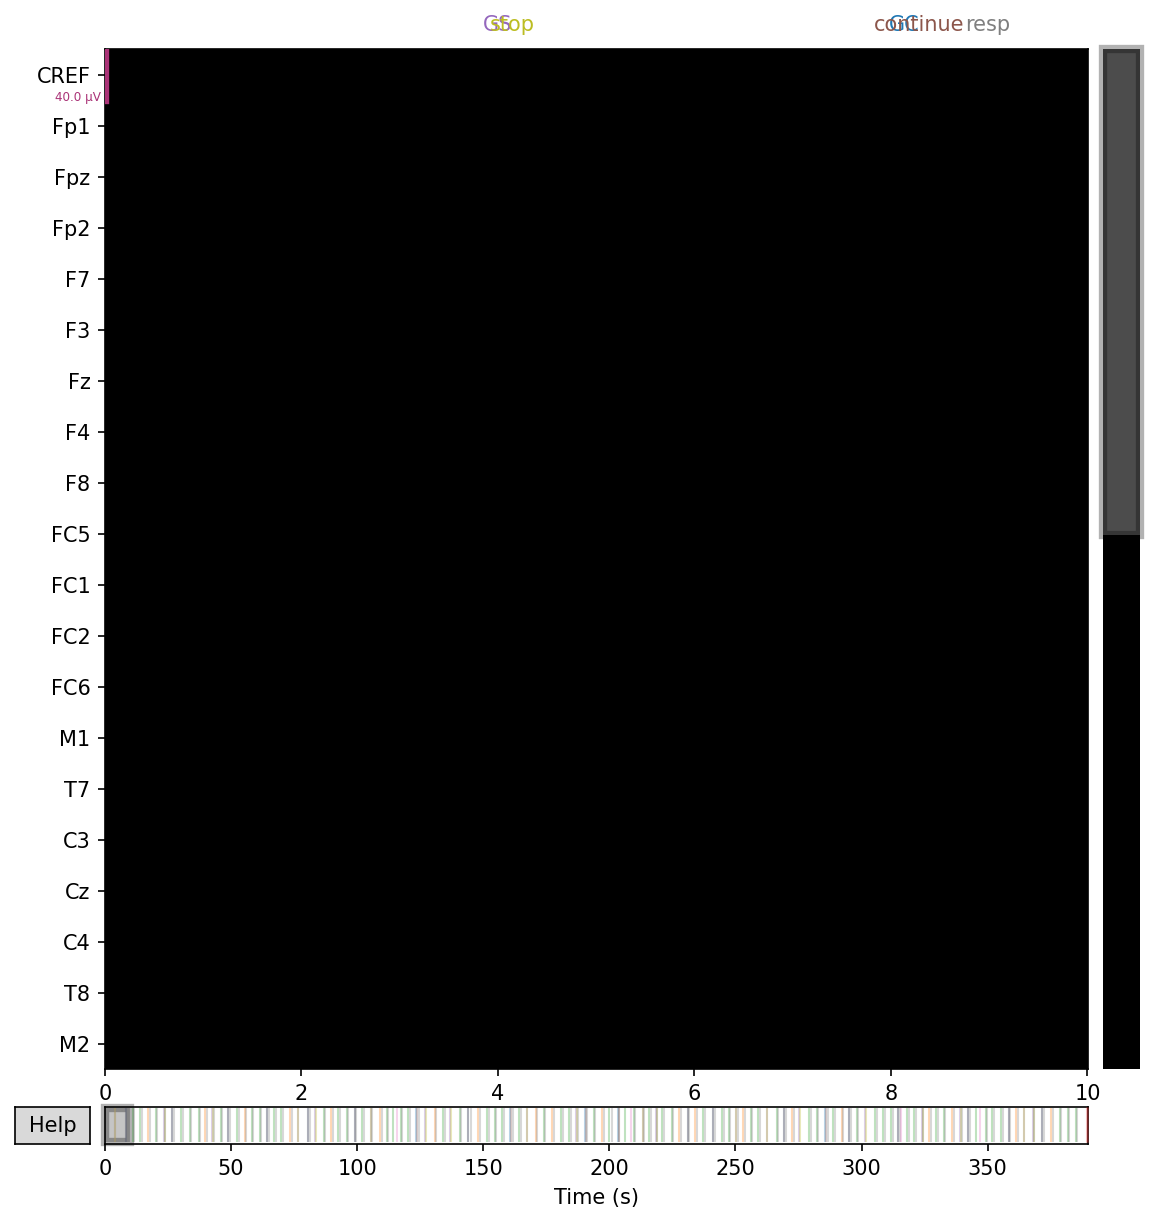

Channels marked as bad:
none


In [13]:
%matplotlib qt
raw_block1.plot()